In [1]:
import pandas as pd
df = pd.read_csv("data/clean.csv")

In [3]:
df["delivery_status"].value_counts(dropna=False)
print((df["delivery_status"] != "delivered").mean() * 100, "% failed")

8.553333333333333 % failed


In [4]:
print(df["sent_at"].dtype)

object


In [7]:
df["sent_at"] = pd.to_datetime(df["sent_at"], errors="coerce", utc=True, format="mixed")

In [8]:
print(df["sent_at"].dtype)

datetime64[ns, UTC]


In [9]:
df["hour"] = df["sent_at"].dt.hour

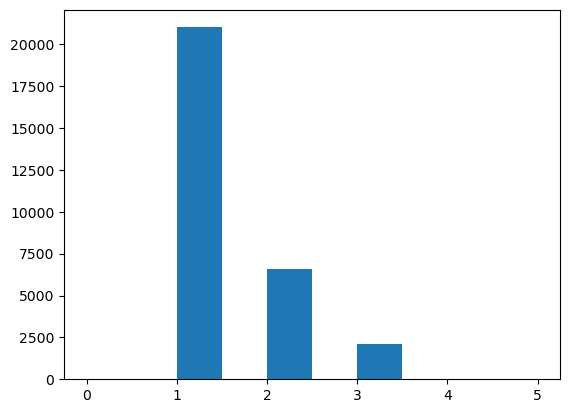

In [40]:
import matplotlib.pyplot as plt
plt.hist(df["message_parts"], bins = 10, range=(0,5))
plt.show()

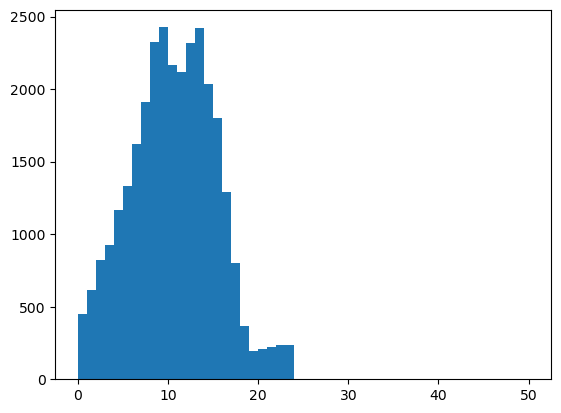

In [45]:
plt.hist(df["hour"], bins = 50, range=(0,50))
plt.show()

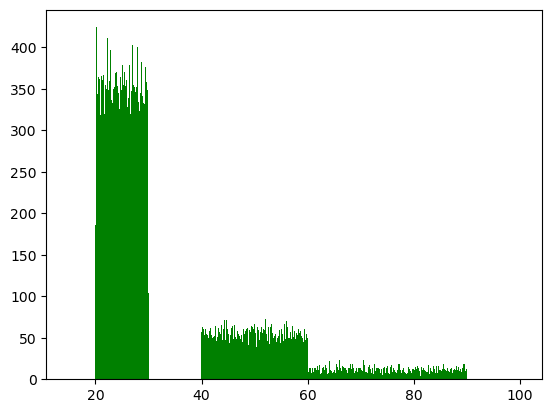

In [42]:
plt.hist(df["cost"], bins=500, range = (15,100), color = "green")
plt.show()

In [51]:
df["is_failed"] = (df["delivery_status"] != "delivered").astype(int)
df.groupby("network_provider")["is_failed"].mean().sort_values()

network_provider
Provider_A          0.067204
Provider_B          0.079678
Unknown Provider    0.098616
Provider_C          0.099931
Provider_D          0.147191
Name: is_failed, dtype: float64

In [52]:
df.groupby("hour")["is_failed"].mean()

hour
0     0.102908
1     0.146341
2     0.083840
3     0.064655
4     0.089194
5     0.075997
6     0.087438
7     0.083159
8     0.073213
9     0.076669
10    0.079945
11    0.083648
12    0.079413
13    0.087459
14    0.085546
15    0.072737
16    0.086047
17    0.066167
18    0.149864
19    0.165803
20    0.120773
21    0.176471
22    0.174468
23    0.134454
Name: is_failed, dtype: float64

In [54]:
df.groupby("message_parts")["is_failed"].mean()

message_parts
1.0    0.074522
2.0    0.101836
3.0    0.131155
Name: is_failed, dtype: float64

In [86]:
print("Provider D ni buh failure-iin 14%-d hamaatai, tegeheer Provider D faildeh handlagatai xD. 19-22 tsagiin hoorond message-uud mun fail-deh handlagatai, 17 garui % fail-dsen. urt parttai message-uud 6-3%-aar iluu faildeh magadlaltai, faildsen baina")

Provider D ni buh failure-iin 17%-d hamaatai, tegeheer Provider D faildeh handlagatai xD. 19-22 tsagiin hoorond message-uud mun fail-deh handlagatai, 14 garui % fail-dsen. urt parttai message-uud 6-3%-aar iluu faildeh magadlaltai, faildsen baina


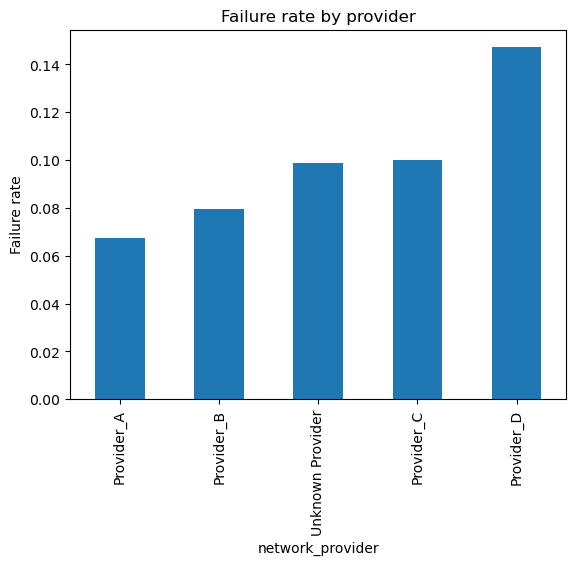

In [57]:
df.groupby("network_provider")["is_failed"].mean().sort_values().plot(kind="bar")
plt.title("Failure rate by provider")
plt.ylabel("Failure rate")
plt.show()

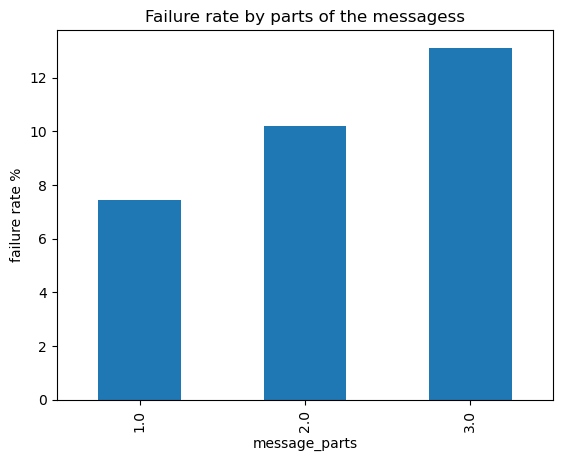

In [60]:
miss = (df.groupby("message_parts")["is_failed"].mean().sort_values())*100
miss.plot(kind = "bar")
plt.title("Failure rate by parts of the messagess")
plt.ylabel("failure rate %")
plt.show()

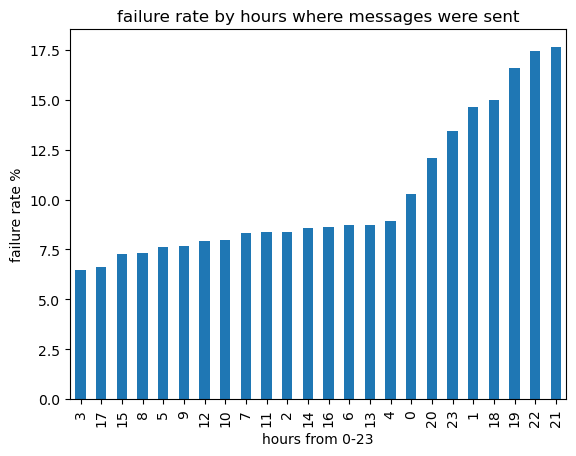

In [64]:
another_miss = (df.groupby("hour")["is_failed"].mean().sort_values())*100
another_miss.plot(kind="bar")
plt.title("failure rate by hours where messages were sent")
plt.ylabel("failure rate %")
plt.xlabel("hours from 0-23")
plt.show()

In [80]:
df.groupby("campaign_id")["is_failed"].mean().sort_values(ascending = False)

campaign_id
CMP008    0.111811
CMP041    0.110749
CMP032    0.102007
CMP012    0.101695
CMP043    0.099533
CMP003    0.099187
CMP026    0.097844
CMP046    0.096055
CMP018    0.095563
CMP024    0.094017
CMP019    0.094017
CMP029    0.093913
CMP011    0.093458
CMP001    0.092084
CMP038    0.091653
CMP016    0.091371
CMP031    0.091057
CMP039    0.090265
CMP028    0.088962
CMP045    0.088481
CMP020    0.088415
CMP006    0.088050
CMP022    0.087719
CMP049    0.087395
CMP004    0.086655
CMP044    0.086538
CMP030    0.083882
CMP048    0.083192
CMP035    0.082792
CMP033    0.082540
CMP050    0.082372
CMP013    0.082312
CMP017    0.081340
CMP025    0.079661
CMP015    0.078905
CMP047    0.078740
CMP027    0.078632
CMP010    0.078261
CMP009    0.077744
CMP036    0.077572
CMP021    0.076792
CMP037    0.076285
CMP023    0.075534
CMP040    0.074199
CMP014    0.070934
CMP042    0.069966
CMP034    0.067944
CMP002    0.064799
CMP005    0.063830
CMP007    0.055749
Name: is_failed, dtype: float64

In [74]:
df.groupby(["campaign_id","network_provider"])["is_failed"].mean().sort_values(ascending = False)

campaign_id  network_provider
CMP012       Provider_D          0.309524
CMP018       Unknown Provider    0.300000
CMP012       Unknown Provider    0.235294
CMP043       Unknown Provider    0.235294
CMP049       Provider_D          0.234043
                                   ...   
CMP019       Unknown Provider    0.000000
CMP038       Unknown Provider    0.000000
CMP021       Unknown Provider    0.000000
CMP044       Unknown Provider    0.000000
CMP008       Unknown Provider    0.000000
Name: is_failed, Length: 250, dtype: float64

In [79]:
df.groupby(["campaign_id", "network_provider"])["is_failed"].agg(["mean", "count"]).sort_values("mean", ascending = False)

,,mean,count
campaign_id,network_provider,,
CMP012,Provider_D,0.309524,42
CMP018,Unknown Provider,0.300000,10
CMP012,Unknown Provider,0.235294,17
CMP043,Unknown Provider,0.235294,17
CMP049,Provider_D,0.234043,47
...,...,...,...
CMP019,Unknown Provider,0.000000,13
CMP038,Unknown Provider,0.000000,6
CMP021,Unknown Provider,0.000000,14


In [82]:
df.groupby("account_id")["is_failed"].mean().sort_values(ascending = False)

account_id
ACC0041    0.138686
ACC0057    0.137255
ACC0179    0.136646
ACC0140    0.136364
ACC0018    0.136364
             ...   
ACC0143    0.040541
ACC0060    0.040541
ACC0046    0.034965
ACC0104    0.033784
ACC0145    0.031847
Name: is_failed, Length: 200, dtype: float64

In [83]:
df.groupby(["account_id", "campaign_id"])["is_failed"].mean().sort_values(ascending = False)

account_id  campaign_id
ACC0140     CMP027         1.0
ACC0179     CMP050         1.0
ACC0110     CMP048         1.0
ACC0163     CMP043         1.0
ACC0110     CMP046         1.0
                          ... 
ACC0076     CMP016         0.0
            CMP015         0.0
            CMP014         0.0
            CMP012         0.0
ACC0100     CMP047         0.0
Name: is_failed, Length: 9487, dtype: float64

In [85]:
df.groupby(["account_id","campaign_id"])["is_failed"].agg(["mean","count"]).sort_values("mean",ascending = False)

mean  count
account_id campaign_id             
ACC0140    CMP027        1.0      1
ACC0179    CMP050        1.0      1
ACC0110    CMP048        1.0      1
ACC0163    CMP043        1.0      1
ACC0110    CMP046        1.0      1
...                      ...    ...
ACC0076    CMP016        0.0      1
           CMP015        0.0      2
           CMP014        0.0      3
           CMP012        0.0      5
ACC0100    CMP047        0.0      3

[9487 rows x 2 columns]

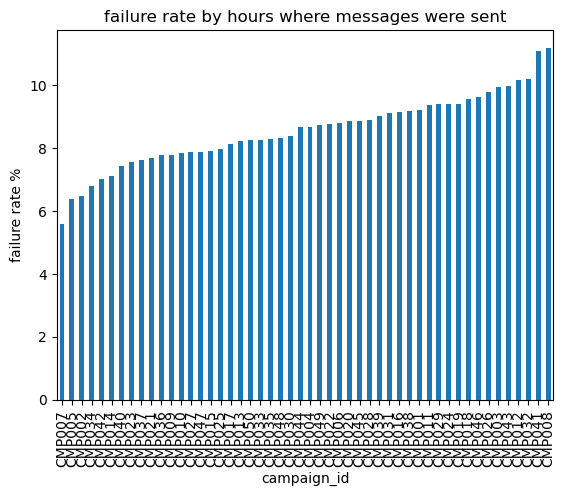

In [88]:
anotha_miss = (df.groupby("campaign_id")["is_failed"].mean().sort_values())*100
anotha_miss.plot(kind="bar")
plt.title("failure rate by hours where messages were sent")
plt.ylabel("failure rate %")
plt.show()

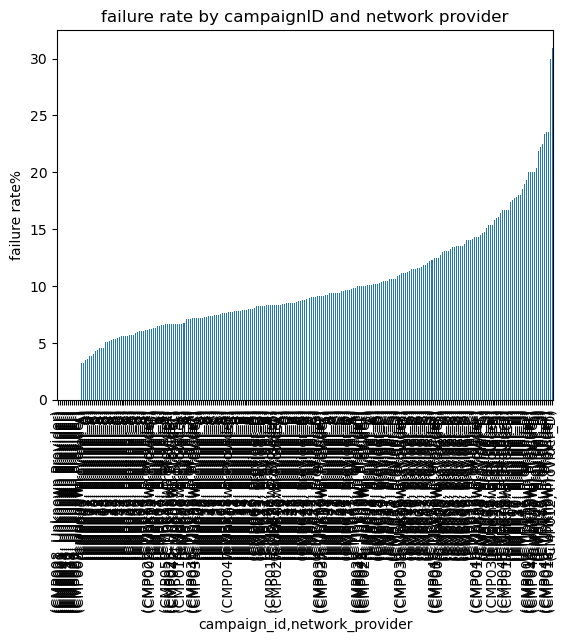

In [90]:
little_miss = (df.groupby(["campaign_id", "network_provider"])["is_failed"].mean().sort_values())*100
little_miss.plot(kind="bar")
plt.title("failure rate by campaignID and network provider")
plt.ylabel("failure rate%")
plt.show()

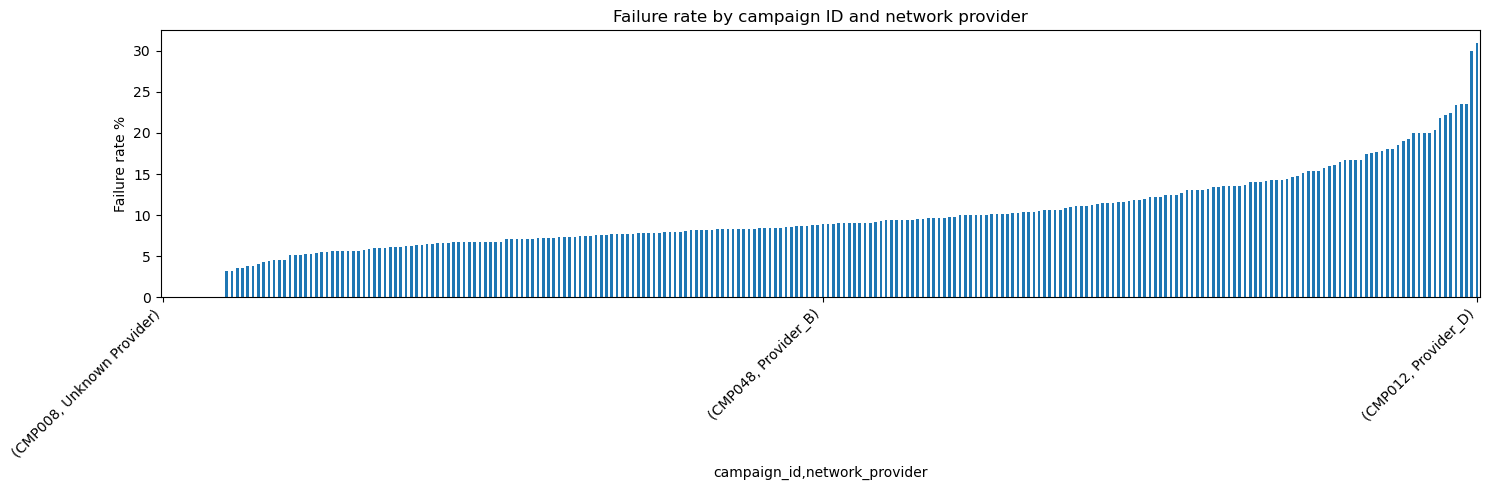

In [95]:
little_miss = df.groupby(["campaign_id", "network_provider"])["is_failed"].mean().sort_values() * 100

fig, ax = little_miss.plot(kind="bar", figsize=(15,5)), plt.gca()

n = len(little_miss)
ax.set_xticks([0, n//2, n-1])  

plt.title("Failure rate by campaign ID and network provider")
plt.ylabel("Failure rate %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()